### Import Required Libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, KFold,cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Load Datasets

In [75]:
# drought dataset
spei = pd.read_csv("SPEI_0.75_35.75.csv")

# precipitation dataset
rain = pd.read_excel("monthly gridded pptn 2019-2024 (1).xlsx",
                     sheet_name="monthly gridded pptn 2019-2024")

tmax = pd.read_excel("monthly gridded pptn 2019-2024 (1).xlsx",
                     sheet_name="monthly gridded tmax 2019-2024")

tmin = pd.read_excel("monthly gridded pptn 2019-2024 (1).xlsx",
                     sheet_name="monthly gridded tmin 2019-2024")

### Clean Drought Dataset

In [76]:
# extract metadata
# parse date 
spei["date"] = pd.to_datetime(spei["DATA"], format="%b%Y", errors="coerce")

# keep matching period only
spei = spei[(spei["date"] >= "2019-01-01") & (spei["date"] <= "2024-12-01")].copy()

# keep useful SPEI scales
spei = spei[["date", "SPEI_1", "SPEI_3", "SPEI_6", "SPEI_12"]]

print(spei.head())
print(spei.shape)

          date   SPEI_1   SPEI_3   SPEI_6  SPEI_12
828 2019-01-01  0.03930  0.24262 -0.23133  1.53012
829 2019-02-01 -0.53185  0.22618 -0.09578  1.36099
830 2019-03-01 -0.94066 -0.93436 -0.07414  0.90310
831 2019-04-01 -1.03191 -1.42567 -0.87047 -0.05929
832 2019-05-01 -0.81321 -1.48783 -1.12400 -0.84499
(72, 5)


### Clean Excel Climate Data

In [77]:
def clean_gridded(df, value_name):
    # force simple column names
    df = df.copy()
    df.columns = ["period", value_name]

    # remove blank rows
    df = df.dropna(subset=["period"]).copy()

    # keep only rows where period looks like YYYYMM
    df["period"] = df["period"].astype(str).str.strip()
    df = df[df["period"].str.fullmatch(r"\d{6}")].copy()

    # convert YYYYMM to datetime
    df["date"] = pd.to_datetime(df["period"], format="%Y%m", errors="coerce")

    # numeric climate values
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    # drop bad rows
    df = df.dropna(subset=["date", value_name]).copy()

    return df[["date", value_name]]

In [78]:
pptn = clean_gridded(rain, "rainfall")
tmax = clean_gridded(tmax, "tmax")
tmin = clean_gridded(tmin, "tmin")

df_climate = pptn.merge(tmax, on="date").merge(tmin, on="date")

print(df_climate.head())
print(df_climate.tail())
print(df_climate.shape)

        date  rainfall      tmax      tmin
0 2019-01-01    23.309  27.02848  12.31526
1 2019-02-01    28.977  27.70414  13.95043
2 2019-03-01    63.319  29.06606  13.70274
3 2019-04-01   133.315  29.01347  14.85820
4 2019-05-01    92.008  27.86090  15.09035
         date  rainfall      tmax      tmin
67 2024-08-01   166.895  22.45190  15.29500
68 2024-09-01    57.071  25.95520  14.30143
69 2024-10-01   144.123  26.56771  15.35126
70 2024-11-01   282.259  24.84017  15.23657
71 2024-12-01    29.129  25.63916  14.37090
(72, 4)


### Merge the two datasets 

In [79]:
# df is your merged precipitation + tmax + tmin dataframe
df = df_climate.merge(spei, on="date", how="inner")

print(df.head())
print(df.shape)

        date  rainfall      tmax      tmin   SPEI_1   SPEI_3   SPEI_6  SPEI_12
0 2019-01-01    23.309  27.02848  12.31526  0.03930  0.24262 -0.23133  1.53012
1 2019-02-01    28.977  27.70414  13.95043 -0.53185  0.22618 -0.09578  1.36099
2 2019-03-01    63.319  29.06606  13.70274 -0.94066 -0.93436 -0.07414  0.90310
3 2019-04-01   133.315  29.01347  14.85820 -1.03191 -1.42567 -0.87047 -0.05929
4 2019-05-01    92.008  27.86090  15.09035 -0.81321 -1.48783 -1.12400 -0.84499
(72, 8)


### Feature Engineering

In [80]:
data = df.copy()

# ensure sorted by date
data = data.sort_values("date").reset_index(drop=True)

In [81]:
data["month"] = data["date"].dt.month
data["year"] = data["date"].dt.year
data["quarter"] = data["date"].dt.quarter

# cyclical month encoding
data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

In [82]:
# Temperature features
data["temp_mean"] = (data["tmax"] + data["tmin"]) / 2
data["temp_range"] = data["tmax"] - data["tmin"]

# Rolling statistics
data["rain_3m_mean"] = data["rainfall"].rolling(window=3).mean()
data["rain_6m_mean"] = data["rainfall"].rolling(window=6).mean()

data["tmax_3m_mean"] = data["tmax"].rolling(window=3).mean()
data["tmin_3m_mean"] = data["tmin"].rolling(window=3).mean()
data["temp_mean_3m"] = data["temp_mean"].rolling(window=3).mean()

data["rain_3m_std"] = data["rainfall"].rolling(window=3).std()
data["temp_mean_3m_std"] = data["temp_mean"].rolling(window=3).std()

In [83]:
# Lag features
for lag in [1, 2, 3]:
    data[f"rainfall_lag_{lag}"] = data["rainfall"].shift(lag)
    data[f"tmax_lag_{lag}"] = data["tmax"].shift(lag)
    data[f"tmin_lag_{lag}"] = data["tmin"].shift(lag)
    data[f"SPEI_3_lag_{lag}"] = data["SPEI_3"].shift(lag)
    data[f"SPEI_6_lag_{lag}"] = data["SPEI_6"].shift(lag)

# Anomaly features
data["rain_anomaly_3m"] = data["rainfall"] - data["rain_3m_mean"]
data["temp_anomaly_3m"] = data["temp_mean"] - data["temp_mean_3m"]

### Creation of Risk Target

In [84]:
def classify_risk(row, rain_high_threshold):
    # drought condition
    if row["SPEI_3"] <= -0.01 or (row["SPEI_6"] <= -0.1):
        return "drought"
    
    # wet/flood condition
    elif (row["rainfall"] >= rain_high_threshold):
        return "flood"
    
    else:
        return "normal"

rain_high_threshold = data["rainfall"].quantile(0.60)

data["risk_level"] = data.apply(
    lambda row: classify_risk(row, rain_high_threshold),
    axis=1
)

print(data["risk_level"].value_counts())

risk_level
drought    25
normal     24
flood      23
Name: count, dtype: int64


In [85]:
rain_high_threshold = data["rainfall"].quantile(0.80)
data["risk_level"] = data.apply(lambda row: classify_risk(row, rain_high_threshold), axis=1)
data["future_risk_level"] = data["risk_level"].shift(-1)

numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].ffill().bfill()
data = data.dropna(subset=["future_risk_level"]).reset_index(drop=True)

In [86]:
# create future target for early warning
data = data.sort_values("date").reset_index(drop=True)
data["future_risk_level"] = data["risk_level"].shift(-1)

print(data[["date", "risk_level", "future_risk_level"]].tail())

         date risk_level future_risk_level
66 2024-07-01     normal           drought
67 2024-08-01    drought            normal
68 2024-09-01     normal            normal
69 2024-10-01     normal             flood
70 2024-11-01      flood               NaN


In [87]:
data.columns

Index(['date', 'rainfall', 'tmax', 'tmin', 'SPEI_1', 'SPEI_3', 'SPEI_6',
       'SPEI_12', 'month', 'year', 'quarter', 'month_sin', 'month_cos',
       'temp_mean', 'temp_range', 'rain_3m_mean', 'rain_6m_mean',
       'tmax_3m_mean', 'tmin_3m_mean', 'temp_mean_3m', 'rain_3m_std',
       'temp_mean_3m_std', 'rainfall_lag_1', 'tmax_lag_1', 'tmin_lag_1',
       'SPEI_3_lag_1', 'SPEI_6_lag_1', 'rainfall_lag_2', 'tmax_lag_2',
       'tmin_lag_2', 'SPEI_3_lag_2', 'SPEI_6_lag_2', 'rainfall_lag_3',
       'tmax_lag_3', 'tmin_lag_3', 'SPEI_3_lag_3', 'SPEI_6_lag_3',
       'rain_anomaly_3m', 'temp_anomaly_3m', 'risk_level',
       'future_risk_level'],
      dtype='str')

### Prepare Features and Target

In [88]:
feature_cols = [
    "rainfall",
    "tmax",
    "tmin",
    "temp_mean",
    "temp_range",
    "SPEI_1",
    "SPEI_3",
    "SPEI_6",
    "SPEI_12",
    "rain_3m_mean",
    "rain_6m_mean",
    "tmax_3m_mean",
    "tmin_3m_mean",
    "temp_mean_3m",
    "rain_3m_std",
    "temp_mean_3m_std",
    "rainfall_lag_1",
    "rainfall_lag_2",
    "rainfall_lag_3",
    "tmax_lag_1",
    "tmax_lag_2",
    "tmax_lag_3",
    "tmin_lag_1",
    "tmin_lag_2",
    "tmin_lag_3",
    "SPEI_3_lag_1",
    "SPEI_3_lag_2",
    "SPEI_3_lag_3",
    "SPEI_6_lag_1",
    "SPEI_6_lag_2",
    "SPEI_6_lag_3",
    "rain_anomaly_3m",
    "temp_anomaly_3m",
    "month_sin",
    "month_cos",
]

X = data[feature_cols]
y = data["risk_level"]

print(X.shape, y.shape)

(71, 35) (71,)


### Train-test split

In [89]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (56, 35)
Test size: (15, 35)


### LSTM Model

In [90]:
# prepare data for LSTM

# features used by the LSTM to forecast next-month rainfall
series_df = data[[
    "rainfall",
    "tmax",
    "tmin",
    "temp_mean",
    "temp_range",
    "SPEI_1",
    "SPEI_3",
    "SPEI_6",
    "SPEI_12",
    "month_sin",
    "month_cos"
]].copy()

scaler_lstm = MinMaxScaler()
series_scaled = scaler_lstm.fit_transform(series_df)

lookback = 6
target_col_index = series_df.columns.get_loc("rainfall")

def create_sequences(dataset, target_col_index, lookback=6):
    X_seq, y_seq = [], []
    for i in range(lookback, len(dataset)):
        X_seq.append(dataset[i-lookback:i, :])
        y_seq.append(dataset[i, target_col_index])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = create_sequences(series_scaled, target_col_index, lookback=lookback)

print("X_lstm shape:", X_lstm.shape)
print("y_lstm shape:", y_lstm.shape)

X_lstm shape: (65, 6, 11)
y_lstm shape: (65,)


In [91]:
# train-test split for LSTM

split_lstm = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split_lstm]
X_test_lstm = X_lstm[split_lstm:]

y_train_lstm = y_lstm[:split_lstm]
y_test_lstm = y_lstm[split_lstm:]

print(X_train_lstm.shape, X_test_lstm.shape)

(52, 6, 11) (13, 6, 11)


In [92]:
# build and train the LSTM
n_features = X_train_lstm.shape[2]

lstm_model = Sequential([
    LSTM(32, activation="tanh", return_sequences=True, input_shape=(lookback, n_features)),
    Dropout(0.2),
    LSTM(16, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/home/vodca/Projects/EdwikeProject/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.1427 - val_loss: 0.0560
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0652 - val_loss: 0.0429
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0528 - val_loss: 0.0584
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0589 - val_loss: 0.0510
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0498 - val_loss: 0.0421
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0452 - val_loss: 0.0418
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0536 - val_loss: 0.0419
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0561 - val_loss: 0.0427
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0383 - val_loss: 0.0453
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0403 - val_loss: 0.0487
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0487 - val_loss: 0.0477
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0469 - val_loss: 0.0450
E

In [93]:
# LSTM prediction and evaluation

# predict
y_pred_lstm = lstm_model.predict(X_test_lstm, verbose=0)

# inverse scaling helper
dummy_pred = np.zeros((len(y_pred_lstm), series_df.shape[1]))
dummy_actual = np.zeros((len(y_test_lstm), series_df.shape[1]))

dummy_pred[:, target_col_index] = y_pred_lstm.flatten()
dummy_actual[:, target_col_index] = y_test_lstm.flatten()

y_pred_inv = scaler_lstm.inverse_transform(dummy_pred)[:, target_col_index]
y_test_inv = scaler_lstm.inverse_transform(dummy_actual)[:, target_col_index]

rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae_lstm = mean_absolute_error(y_test_inv, y_pred_inv)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)

# create a new column in the main dataframe
data["pred_rainfall_next"] = np.nan

# align predictions back to the original rows
# sequences start at row = lookback
# test sequences start at split_lstm within the sequence array
prediction_row_start = lookback + split_lstm
prediction_row_end = prediction_row_start + len(y_pred_inv)

data.loc[prediction_row_start:prediction_row_end-1, "pred_rainfall_next"] = y_pred_inv

print(data[["date", "rainfall", "pred_rainfall_next"]].tail(12))

LSTM RMSE: 107.92208872408882
LSTM MAE: 80.30714398578496
         date  rainfall  pred_rainfall_next
59 2023-12-01    39.407          124.569579
60 2024-01-01   121.434          122.975041
61 2024-02-01   137.153          128.268977
62 2024-03-01    70.468          132.059008
63 2024-04-01   374.824          136.802269
64 2024-05-01   320.941          139.698569
65 2024-06-01    88.258          142.395530
66 2024-07-01   150.692          142.758483
67 2024-08-01   166.895          140.140255
68 2024-09-01    57.071          130.870013
69 2024-10-01   144.123          121.344158
70 2024-11-01   282.259          115.645382


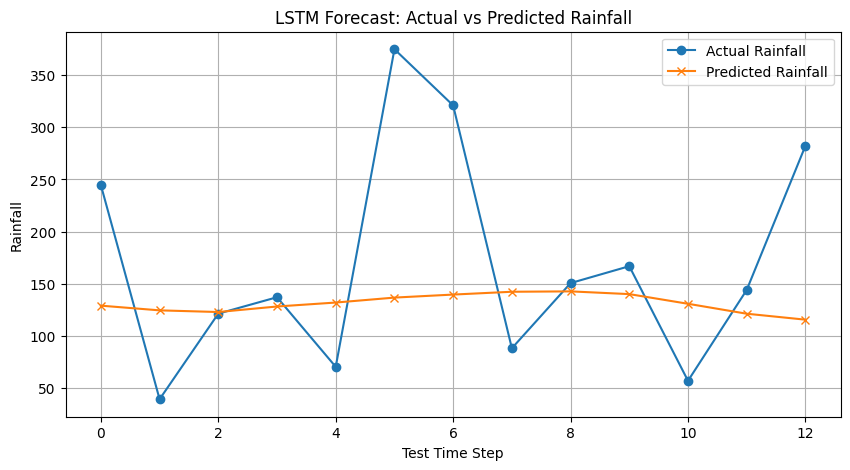

In [94]:
# plot LSTM results

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label="Actual Rainfall", marker="o")
plt.plot(y_pred_inv, label="Predicted Rainfall", marker="x")
plt.title("LSTM Forecast: Actual vs Predicted Rainfall")
plt.xlabel("Test Time Step")
plt.ylabel("Rainfall")
plt.legend()
plt.grid(True)
plt.show()

## Hybrid RF Classifier

In [95]:
# use only rows where the LSTM prediction exists
hybrid_data = data.dropna(subset=["pred_rainfall_next", "future_risk_level"]).copy()

feature_cols_hybrid = [
    "rainfall",
    "tmax",
    "tmin",
    "temp_mean",
    "temp_range",
    "SPEI_1",
    "SPEI_3",
    "SPEI_6",
    "SPEI_12",
    "rain_3m_mean",
    "rain_6m_mean",
    "tmax_3m_mean",
    "tmin_3m_mean",
    "rainfall_lag_1",
    "rainfall_lag_2",
    "rainfall_lag_3",
    "tmax_lag_1",
    "tmax_lag_2",
    "tmax_lag_3",
    "tmin_lag_1",
    "tmin_lag_2",
    "tmin_lag_3",
    "SPEI_3_lag_1",
    "SPEI_3_lag_2",
    "SPEI_3_lag_3",
    "SPEI_6_lag_1",
    "SPEI_6_lag_2",
    "SPEI_6_lag_3",
    "month_sin",
    "month_cos",
    "pred_rainfall_next"
]

X_hybrid = hybrid_data[feature_cols_hybrid].copy()
y_hybrid = hybrid_data["future_risk_level"].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_hybrid)

# time-based split
split_index = int(len(hybrid_data) * 0.8)

X_train = X_hybrid.iloc[:split_index].copy()
X_test = X_hybrid.iloc[split_index:].copy()

y_train = y_hybrid.iloc[:split_index].copy()
y_test = y_hybrid.iloc[split_index:].copy()

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(9, 31) (3, 31) (9,) (3,)


In [98]:
tscv = TimeSeriesSplit(n_splits=4)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="f1_weighted",
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Params:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 4 folds for each of 216 candidates, totalling 864 fits
Best Params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 100}
Best CV Score: 0.5


Hybrid Accuracy: 0.6666666666666666
Hybrid F1 (weighted): 0.5333333333333333

              precision    recall  f1-score   support

       flood       0.00      0.00      0.00         1
      normal       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



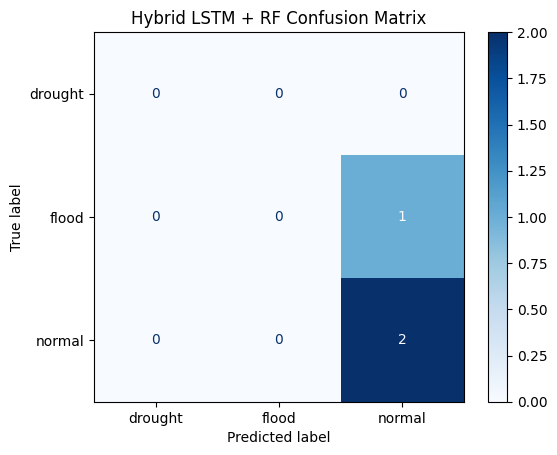

In [ ]:
y_pred_hybrid = best_rf.predict(X_test)

print("Hybrid Accuracy:", accuracy_score(y_test, y_pred_hybrid))
print("Hybrid F1 (weighted):", f1_score(y_test, y_pred_hybrid, average="weighted"))
print()
print(classification_report(y_test, y_pred_hybrid, zero_division=0))

cm = confusion_matrix(y_test, y_pred_hybrid, labels=best_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap="Blues")
plt.title("Hybrid LSTM + RF Confusion Matrix")
plt.show()

               feature  importance
6               SPEI_3    0.157895
12        tmin_3m_mean    0.157895
30  pred_rainfall_next    0.157895
9         rain_3m_mean    0.052632
13      rainfall_lag_1    0.052632
10        rain_6m_mean    0.052632
3            temp_mean    0.052632
22        SPEI_3_lag_1    0.052632
23        SPEI_3_lag_2    0.052632
29           month_cos    0.052632
26        SPEI_6_lag_2    0.052632
21          tmin_lag_3    0.052632
14      rainfall_lag_2    0.052632
5               SPEI_1    0.000000
4           temp_range    0.000000


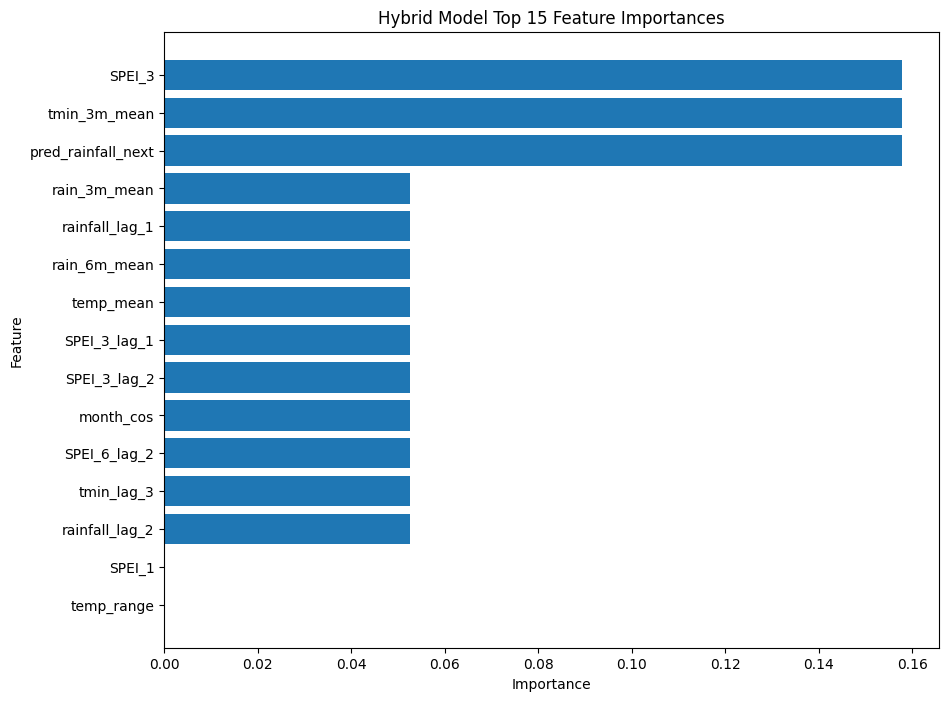

In [ ]:
importance_df = pd.DataFrame({
    "feature": feature_cols_hybrid,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(15))

plt.figure(figsize=(10, 8))
plt.barh(importance_df["feature"][:15][::-1], importance_df["importance"][:15][::-1])
plt.title("Hybrid Model Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
results = X_test.copy()
results["date"] = hybrid_data.iloc[split_index:]["date"].values
results["actual_future_risk"] = y_test.values
results["predicted_future_risk"] = y_pred_hybrid

# optional qualitative alert based on predicted rainfall
results["predicted_rainfall_next"] = X_test["pred_rainfall_next"].values

high_rain_threshold = hybrid_data["rainfall"].quantile(0.80)
low_rain_threshold = hybrid_data["rainfall"].quantile(0.20)

def warning_flag(row):
    if row["predicted_rainfall_next"] >= high_rain_threshold:
        return "Flood Watch"
    elif row["predicted_rainfall_next"] <= low_rain_threshold:
        return "Drought Watch"
    else:
        return "Normal Watch"

results["warning_flag"] = results.apply(warning_flag, axis=1)

results[[
    "date",
    "predicted_rainfall_next",
    "predicted_future_risk",
    "actual_future_risk",
    "warning_flag"
]].tail(12)

,date,predicted_rainfall_next,predicted_future_risk,actual_future_risk,warning_flag
68,2024-09-01,146.654311,normal,normal,Normal Watch
69,2024-10-01,136.329438,normal,flood,Normal Watch
70,2024-11-01,129.192839,normal,normal,Normal Watch


In [ ]:
joblib.dump(best_rf, "best_rf.pkl")
joblib.dump(scaler_lstm, "scaler_lstm.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")
joblib.dump(series_df, "series_features.pkl")
joblib.dump(lookback, "lookback.pkl")
joblib.dump(rain_high_threshold, "rain_high_threshold.pkl")

lstm_model.save("lstm_model.h5")

print("Saved:")
print("- best_rf.pkl")
print("- scaler_lstm.pkl")
print("- label_encoder.pkl")
print("- feature_cols.pkl")
print("- series_features.pkl")
print("- lookback.pkl")
print("- rain_high_threshold.pkl")
print("- lstm_model.h5")

NameError: name 'label_encoder' is not defined